In [ ]:
import os
os.makedirs('/content/drive/MyDrive/sen1floods11', exist_ok=True)
!gsutil -m rsync -r gs://sen1floods11 /content/drive/MyDrive/sen1floods11/


Streaming output truncated to the last 5000 lines.
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2715591_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2768492_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2774101_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2827217_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2829966_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2904649_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2914792_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2929822_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2Weak/India_2944751_S2Weak.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/WeaklyLabeled/S2We

In [22]:
from google.colab import drive

import os
DATA_ROOT = "/content/drive/MyDrive/sen1floods11"

# Show what's inside
print("Contents of sen1floods11/")
if not os.path.exists(DATA_ROOT):
    print(f"Dataset root directory not found: {DATA_ROOT}")
elif not os.path.isdir(DATA_ROOT):
    print(f"Dataset root path is not a directory: {DATA_ROOT}")
else:
    for item in sorted(os.listdir(DATA_ROOT)):
        path = os.path.join(DATA_ROOT, item)
        if os.path.isdir(path):
            count = len(os.listdir(path))
            print(f"  {item}/ ({count} items)")
            if item == "v1.1": # Check subdirectories of v1.1
                for sub_item in sorted(os.listdir(path)):
                    sub_path = os.path.join(path, sub_item)
                    if os.path.isdir(sub_path):
                        sub_count = len(os.listdir(sub_path))
                        print(f"    {sub_item}/ ({sub_count} items)")
                    else:
                        print(f"    {sub_item}")
        else:
            print(f"  {item}")

Contents of sen1floods11/
  v1.1/ (2 items)
    data/ (1 items)
    splits/ (1 items)


In [23]:
import os

DATA_ROOT = "/content/drive/MyDrive/sen1floods11/v1.1"

MAX_FILES_SHOWN = 5  # change this to show more or fewer

def explore(path, max_depth=4, current_depth=0):
    if current_depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
    except:
        return

    dirs = [i for i in items if os.path.isdir(os.path.join(path, i))]
    files = [i for i in items if os.path.isfile(os.path.join(path, i))]

    indent = "  " * current_depth

    # shows all subdirectories
    for item in dirs:
        full_path = os.path.join(path, item)
        count = len(os.listdir(full_path))
        print(f"{indent}{item}/ ({count} items)")
        explore(full_path, max_depth, current_depth + 1)

    # Limit files shown
    for item in files[:MAX_FILES_SHOWN]:
        print(f"{indent}{item}")

    if len(files) > MAX_FILES_SHOWN:
        print(f"{indent}... and {len(files) - MAX_FILES_SHOWN} more files")


for folder in ["data", "splits"]:
    print(f"\n=== {folder}/ ===")
    explore(os.path.join(DATA_ROOT, folder), max_depth=4)



=== data/ ===
flood_events/ (1 items)
  HandLabeled/ (2 items)
    LabelHand/ (446 items)
      Bolivia_103757_LabelHand.tif
      Bolivia_129334_LabelHand.tif
      Bolivia_195474_LabelHand.tif
      Bolivia_23014_LabelHand.tif
      Bolivia_233925_LabelHand.tif
      ... and 441 more files
    S1Hand/ (446 items)
      Bolivia_103757_S1Hand.tif
      Bolivia_129334_S1Hand.tif
      Bolivia_195474_S1Hand.tif
      Bolivia_23014_S1Hand.tif
      Bolivia_233925_S1Hand.tif
      ... and 441 more files

=== splits/ ===
flood_handlabeled/ (4 items)
  flood_bolivia_data.csv
  flood_test_data.csv
  flood_train_data.csv
  flood_valid_data.csv


In [ ]:
import pandas as pd

# Check train split CSV
csv_path = None
splits_root = os.path.join(DATA_ROOT, "splits")
for root, dirs, files in os.walk(splits_root):
    for f in files:
        if f.endswith(".csv"):
            csv_path = os.path.join(root, f)
            print(f"\nFound: {csv_path}")
            df = pd.read_csv(csv_path)
            print(df.head(5))
            print(f"Columns: {df.columns.tolist()}")
            print(f"Shape: {df.shape}")
            break
    if csv_path:
        break


Found: /content/drive/MyDrive/sen1floods11/v1.1/splits/perm_water/permanent_water_test_data.csv
  sentinel_1_289_rural_108.52333175632958_-7.683066787895676.tif  \
0  sentinel_6_370_inhabited_-76.95854151986643_50...               
1  sentinel_4_341_rural_-92.14135253314852_35.497...               
2  sentinel_9_585_inhabited_-60.03003257606975_-3...               
3  sentinel_10_754_inhabited_78.51070554645935_33...               
4  sentinel_4_648_high_density_-5.620790518990652...               

  water_1_289_rural_108.52333175632958_-7.683066787895676.tif  
0  water_6_370_inhabited_-76.95854151986643_50.83...           
1  water_4_341_rural_-92.14135253314852_35.497440...           
2  water_9_585_inhabited_-60.03003257606975_-31.1...           
3  water_10_754_inhabited_78.51070554645935_33.89...           
4  water_4_648_high_density_-5.620790518990652_43...           
Columns: ['sentinel_1_289_rural_108.52333175632958_-7.683066787895676.tif', 'water_1_289_rural_108.52333175632

In [ ]:
import pandas as pd
import os

DATA_ROOT = "/content/drive/MyDrive/sen1floods11/v1.1"

# Check ALL flood handlabeled CSVs
splits_path = os.path.join(DATA_ROOT, "splits/flood_handlabeled")

for csv_file in sorted(os.listdir(splits_path)):
    if csv_file.endswith(".csv"):
        full_path = os.path.join(splits_path, csv_file)
        df = pd.read_csv(full_path)
        print(f"\n=== {csv_file} ===")
        print(f"Shape: {df.shape}")
        print(f"Columns: {df.columns.tolist()}")
        print(df.head(3))


=== flood_bolivia_data.csv ===
Shape: (14, 2)
Columns: ['Bolivia_103757_S1Hand.tif', 'Bolivia_103757_LabelHand.tif']
   Bolivia_103757_S1Hand.tif  Bolivia_103757_LabelHand.tif
0  Bolivia_129334_S1Hand.tif  Bolivia_129334_LabelHand.tif
1  Bolivia_195474_S1Hand.tif  Bolivia_195474_LabelHand.tif
2   Bolivia_23014_S1Hand.tif   Bolivia_23014_LabelHand.tif

=== flood_test_data.csv ===
Shape: (89, 2)
Columns: ['Ghana_313799_S1Hand.tif', 'Ghana_313799_LabelHand.tif']
    Ghana_313799_S1Hand.tif   Ghana_313799_LabelHand.tif
0  Ghana_1078550_S1Hand.tif  Ghana_1078550_LabelHand.tif
1    Ghana_97059_S1Hand.tif    Ghana_97059_LabelHand.tif
2   Ghana_359826_S1Hand.tif   Ghana_359826_LabelHand.tif

=== flood_train_data.csv ===
Shape: (251, 2)
Columns: ['Ghana_103272_S1Hand.tif', 'Ghana_103272_LabelHand.tif']
   Ghana_103272_S1Hand.tif  Ghana_103272_LabelHand.tif
0   Ghana_24858_S1Hand.tif   Ghana_24858_LabelHand.tif
1  Ghana_147015_S1Hand.tif  Ghana_147015_LabelHand.tif
2  Ghana_953791_S1Hand.tif  G

In [3]:
!pip install segmentation-models-pytorch torchgeo rasterio -q #torchgeo for gis torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 124.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:
import os
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from torchgeo.models import ResNet50_Weights
import torchvision.transforms.functional as TF
import random
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [ ]:
# ── Paths ──────────────────────────────────────────────
DATA_ROOT   = "/content/drive/MyDrive/sen1floods11/v1.1"
S1_DIR      = os.path.join(DATA_ROOT, "data/flood_events/HandLabeled/S1Hand")
LABEL_DIR   = os.path.join(DATA_ROOT, "data/flood_events/HandLabeled/LabelHand")
SPLITS_DIR  = os.path.join(DATA_ROOT, "splits/flood_handlabeled")
CKPT_PATH   = "/content/drive/MyDrive/best_flood_model.pth"

# ── Hyperparameters ────────────────────────────────────
IMG_SIZE    = 512       # resize all images to 512×512
BATCH_SIZE  = 8         # reduce to 4 if Colab runs out of memory
NUM_EPOCHS  = 30
LR          = 1e-4
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {DEVICE}")

Using device: cpu


In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


resetting to gpu made runntime disconect and the files werent saved in drive, so now just downlaoded only necessary files.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os

BASE = "/content/drive/MyDrive/sen1floods11/v1.1"

os.makedirs(f"{BASE}/data/flood_events/HandLabeled/S1Hand",    exist_ok=True)
os.makedirs(f"{BASE}/data/flood_events/HandLabeled/LabelHand", exist_ok=True)
os.makedirs(f"{BASE}/splits/flood_handlabeled",                exist_ok=True)

# Verify folders were created
for path in [
    f"{BASE}/data/flood_events/HandLabeled/S1Hand",
    f"{BASE}/data/flood_events/HandLabeled/LabelHand",
    f"{BASE}/splits/flood_handlabeled"
]:
    print(f"{'All Good' if os.path.exists(path) else 'Oops'} {path}")

All Good /content/drive/MyDrive/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand
All Good /content/drive/MyDrive/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand
All Good /content/drive/MyDrive/sen1floods11/v1.1/splits/flood_handlabeled


In [ ]:
# Download 1 — SAR images (~2-3GB) — will take 5-8 mins
!gsutil -m cp "gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/*.tif" \
    /content/drive/MyDrive/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/

Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_129334_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_103757_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_23014_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_195474_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_242570_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_233925_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_312675_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_314919_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_294583_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_290290_S1Hand.tif...
Copying gs://sen1floods11/v1.1/

In [ ]:
# Download 2 — Masks (~100MB) — will take ~1 min
!gsutil -m cp "gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/*.tif" \
    /content/drive/MyDrive/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/

Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_195474_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_23014_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_233925_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_103757_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_129334_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_242570_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_314919_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_312675_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bolivia_294583_LabelHand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand/Bol

In [ ]:
# Download 3 — CSVs (tiny) — seconds
!gsutil -m cp "gs://sen1floods11/v1.1/splits/flood_handlabeled/*.csv" \
    /content/drive/MyDrive/sen1floods11/v1.1/splits/flood_handlabeled/

Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_bolivia_data.csv...
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv...
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv...
Copying gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv...
/ [4/4 files][ 23.5 KiB/ 23.5 KiB] 100% Done                                    
Operation completed over 4 objects/23.5 KiB.                                     


In [26]:
import os

BASE = "/content/drive/MyDrive/sen1floods11/v1.1"

s1_count    = len(os.listdir(f"{BASE}/data/flood_events/HandLabeled/S1Hand"))
label_count = len(os.listdir(f"{BASE}/data/flood_events/HandLabeled/LabelHand"))
csv_count   = len(os.listdir(f"{BASE}/splits/flood_handlabeled"))

print(f"SAR images:  {s1_count}  ")
print(f"Masks:       {label_count}  ")
print(f"CSV files:   {csv_count}   ")

SAR images:  446  
Masks:       446  
CSV files:   4   


In [ ]:
!pip install segmentation-models-pytorch torchgeo rasterio -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.1/688.1 kB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 71.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 127.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [27]:
import os
import numpy as np
import pandas as pd
import rasterio
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from torchgeo.models import ResNet50_Weights
import torchvision.transforms.functional as TF
import random
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR


In [28]:
BASE        = "/content/drive/MyDrive/sen1floods11/v1.1"
S1_DIR      = f"{BASE}/data/flood_events/HandLabeled/S1Hand"
LABEL_DIR   = f"{BASE}/data/flood_events/HandLabeled/LabelHand"
SPLITS_DIR  = f"{BASE}/splits/flood_handlabeled"
CKPT_PATH   = "/content/drive/MyDrive/best_flood_model.pth"

IMG_SIZE    = 512
BATCH_SIZE  = 8
NUM_EPOCHS  = 30
LR          = 1e-4
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device:     {DEVICE}")
print(f"S1 dir:     {S1_DIR}")
print(f"Label dir:  {LABEL_DIR}")
print(f"Splits dir: {SPLITS_DIR}")

Device:     cuda
S1 dir:     /content/drive/MyDrive/sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand
Label dir:  /content/drive/MyDrive/sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand
Splits dir: /content/drive/MyDrive/sen1floods11/v1.1/splits/flood_handlabeled


SAR shape:        (2, 512, 512)
SAR dtype:        float32
SAR value range:  nan  to  nan
SAR channels:     band1=VV, band2=VH

Mask shape:       (512, 512)
Mask unique vals: [-1.  0.  1.]
  → 0 = no flood
  → 1 = flood
  → -1 = invalid/no data pixels

Pixel breakdown:
  Flood:    35362  (13.5%)
  No flood: 52715  (20.1%)
  Invalid:  174067  (66.4%)


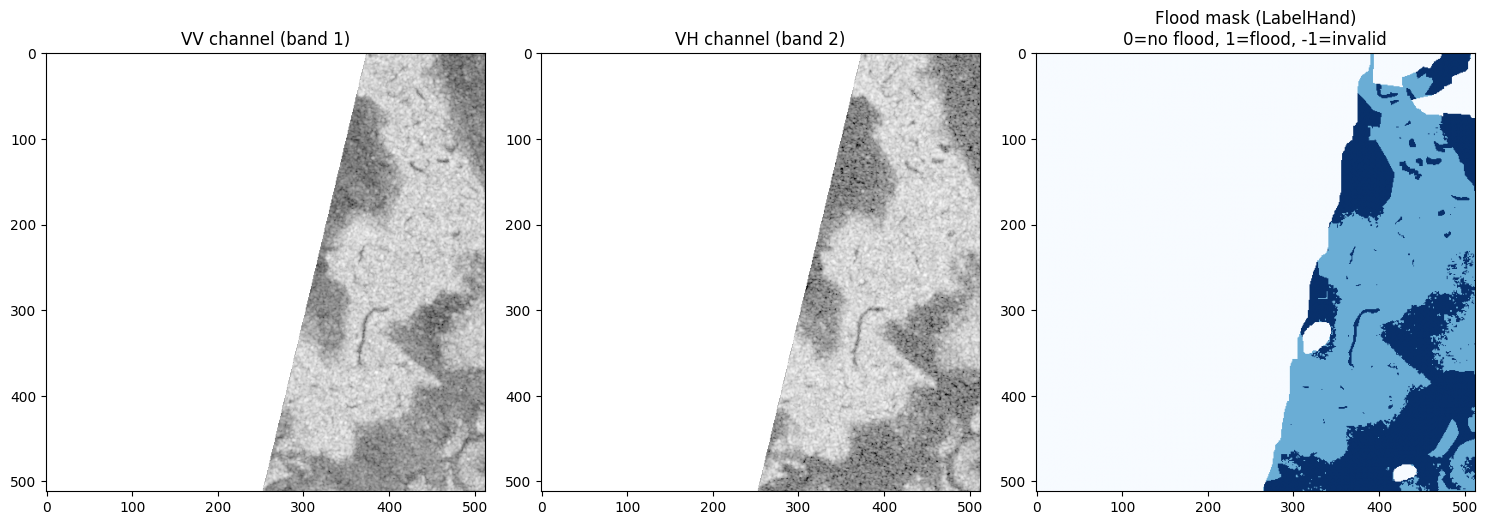

In [29]:
# Pick one file to inspect
sample_s1    = os.path.join(S1_DIR,    "Bolivia_103757_S1Hand.tif")
sample_label = os.path.join(LABEL_DIR, "Bolivia_103757_LabelHand.tif")

# Read SAR
with rasterio.open(sample_s1) as src:
    sar = src.read().astype(np.float32)  # (bands, H, W)
    print(f"SAR shape:        {sar.shape}")
    print(f"SAR dtype:        {sar.dtype}")
    print(f"SAR value range:  {sar.min():.2f}  to  {sar.max():.2f}")
    print(f"SAR channels:     band1=VV, band2=VH")

# Read mask/label
with rasterio.open(sample_label) as src:
    mask = src.read(1).astype(np.float32)  # single band
    print(f"\nMask shape:       {mask.shape}")
    print(f"Mask unique vals: {np.unique(mask)}")
    print(f"  → 0 = no flood")
    print(f"  → 1 = flood")
    print(f"  → -1 = invalid/no data pixels")

# Count flood vs non-flood
total   = mask.size
flood   = (mask == 1).sum()
noflood = (mask == 0).sum()
invalid = (mask == -1).sum()
print(f"\nPixel breakdown:")
print(f"  Flood:    {flood}  ({100*flood/total:.1f}%)")
print(f"  No flood: {noflood}  ({100*noflood/total:.1f}%)")
print(f"  Invalid:  {invalid}  ({100*invalid/total:.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sar[0], cmap='gray')
axes[0].set_title('VV channel (band 1)')
axes[1].imshow(sar[1], cmap='gray')
axes[1].set_title('VH channel (band 2)')
axes[2].imshow(mask, cmap='Blues')
axes[2].set_title('Flood mask (LabelHand)\n0=no flood, 1=flood, -1=invalid')
plt.tight_layout()
plt.show()

In [30]:
class Sen1Floods11Dataset(Dataset):
    def __init__(self, csv_path, s1_dir, label_dir, img_size=512, augment=False):

        df = pd.read_csv(csv_path, header=None)
        self.s1_paths    = [os.path.join(s1_dir,    f) for f in df[0].tolist()]
        self.label_paths = [os.path.join(label_dir, f) for f in df[1].tolist()]
        self.img_size    = img_size
        self.augment     = augment

    def __len__(self):
        return len(self.s1_paths)

    def __getitem__(self, idx):
        #  Load SAR image
        with rasterio.open(self.s1_paths[idx]) as src:
            sar = src.read().astype(np.float32)   # (2, H, W)

        #  Load mask/label
        with rasterio.open(self.label_paths[idx]) as src:
            mask = src.read(1).astype(np.float32) # (H, W)

        #  Handle invalid pixels
        # -1 means no data → treat as no flood (0)
        mask[mask == -1] = 0
        sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)

        #  Normalize using SSL4EO-S12 SAR statistics
        # These exact mean/std values come from SSL4EO-S12 pretraining
        # MUST match what the pretrained encoder expects
        mean = np.array([-12.59, -20.26], dtype=np.float32).reshape(2, 1, 1)
        std  = np.array([  5.26,   5.91], dtype=np.float32).reshape(2, 1, 1)
        sar  = (sar - mean) / std

        #  To tensors
        sar  = torch.from_numpy(sar)               # (2, H, W)
        mask = torch.from_numpy(mask).unsqueeze(0) # (1, H, W)

        #  Resize
        sar  = TF.resize(sar,  [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.img_size, self.img_size],
                         interpolation=TF.InterpolationMode.NEAREST)

        #  Augmentation (train only)
        if self.augment:
            if random.random() > 0.5:
                sar  = TF.hflip(sar)
                mask = TF.hflip(mask)
            if random.random() > 0.5:
                sar  = TF.vflip(sar)
                mask = TF.vflip(mask)

        return sar, mask

In [31]:
train_dataset = Sen1Floods11Dataset(
    csv_path  = f"{SPLITS_DIR}/flood_train_data.csv",
    s1_dir    = S1_DIR,
    label_dir = LABEL_DIR,
    img_size  = IMG_SIZE,
    augment   = True    # only train gets augmentation
)
val_dataset = Sen1Floods11Dataset(
    csv_path  = f"{SPLITS_DIR}/flood_valid_data.csv",
    s1_dir    = S1_DIR,
    label_dir = LABEL_DIR,
    img_size  = IMG_SIZE,
    augment   = False
)
test_dataset = Sen1Floods11Dataset(
    csv_path  = f"{SPLITS_DIR}/flood_test_data.csv",
    s1_dir    = S1_DIR,
    label_dir = LABEL_DIR,
    img_size  = IMG_SIZE,
    augment   = False
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

# Quick sanity check — load one batch and check shapes
sar_batch, mask_batch = next(iter(train_loader))
print(f"\nSAR batch shape:  {sar_batch.shape}")   # (8, 2, 512, 512)
print(f"Mask batch shape: {mask_batch.shape}")    # (8, 1, 512, 512)
print("DataLoaders ready ✅")

Train samples: 252
Val samples:   89
Test samples:  90

SAR batch shape:  torch.Size([8, 2, 512, 512])
Mask batch shape: torch.Size([8, 1, 512, 512])
DataLoaders ready ✅


In [32]:
import timm
from torchgeo.models import ResNet50_Weights

# Step 1 — Build SMP UNet
model = smp.Unet(
    encoder_name    = "resnet50",
    encoder_weights = None,
    in_channels     = 2,
    classes         = 1,
    activation      = None
)

# Step 2 — Load SSL4EO weights into timm ResNet50
weights     = ResNet50_Weights.SENTINEL1_ALL_MOCO
timm_resnet = timm.create_model(
    'resnet50',
    in_chans    = 2,
    num_classes = 0,
    pretrained  = False
)

missing, unexpected = timm_resnet.load_state_dict(
    weights.get_state_dict(progress=True),
    strict=False
)
print(f"timm load — Missing: {missing} | Unexpected: {unexpected}")
# Both should be [] — weights loaded perfectly into timm

# Step 3 — Transfer timm weights → SMP encoder
timm_state = timm_resnet.state_dict()
model.encoder.load_state_dict(timm_state, strict=False)

# Step 4 — Verify transfer worked by comparing actual weight values
smp_weight  = model.encoder.state_dict()['conv1.weight']
timm_weight = timm_state['conv1.weight']
weights_match = torch.allclose(smp_weight, timm_weight)
print(f"Weights transferred correctly: {weights_match} ✅")

# Step 5 — Move to device
model = model.to(DEVICE)

encoder_params = sum(p.numel() for p in model.encoder.parameters())
decoder_params = sum(p.numel() for p in model.decoder.parameters())
total_params   = sum(p.numel() for p in model.parameters())

print(f"\nEncoder params: {encoder_params:,}  ← pretrained SAR weights")
print(f"Decoder params: {decoder_params:,}  ← randomly initialized")
print(f"Total params:   {total_params:,}")
print(f"Model on:       {DEVICE} ✅")

timm load — Missing: [] | Unexpected: []
Weights transferred correctly: True ✅

Encoder params: 23,504,896  ← pretrained SAR weights
Decoder params: 9,012,928  ← randomly initialized
Total params:   32,517,969
Model on:       cuda ✅


In [33]:
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss  = smp.losses.SoftBCEWithLogitsLoss()

def loss_fn(pred, mask):
    return dice_loss(pred, mask) + bce_loss(pred, mask)

def compute_metrics(preds, masks, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    masks = masks.float()

    intersection = (preds * masks).sum()
    union        = preds.sum() + masks.sum() - intersection
    iou          = (intersection + 1e-6) / (union + 1e-6)

    precision    = (intersection + 1e-6) / (preds.sum() + 1e-6)
    recall       = (intersection + 1e-6) / (masks.sum() + 1e-6)
    f1           = 2 * precision * recall / (precision + recall + 1e-6)

    return iou.item(), f1.item(), precision.item(), recall.item()

print("Loss and metrics ready ✅")

Loss and metrics ready ✅


In [ ]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

best_val_iou = 0.0
history      = {"train_loss": [], "val_loss": [], "val_iou": [], "val_f1": []}

for epoch in range(NUM_EPOCHS):

    #  TRAIN
    model.train()
    train_loss = 0.0

    for sar, mask in train_loader:
        sar, mask = sar.to(DEVICE), mask.to(DEVICE)
        optimizer.zero_grad()
        pred = model(sar)
        loss = loss_fn(pred, mask)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    #  VALIDATE
    model.eval()
    val_loss, val_iou, val_f1 = 0.0, 0.0, 0.0

    with torch.no_grad():
        for sar, mask in val_loader:
            sar, mask  = sar.to(DEVICE), mask.to(DEVICE)
            pred       = model(sar)
            loss       = loss_fn(pred, mask)
            iou, f1    = compute_metrics(pred, mask)
            val_loss  += loss.item()
            val_iou   += iou
            val_f1    += f1

    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)
    val_f1   /= len(val_loader)
    scheduler.step()

    #  Save best checkpoint
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), CKPT_PATH)
        saved = "✅ saved"
    else:
        saved = ""

    #  Log
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch+1:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val IoU: {val_iou:.4f} | "
          f"Val F1: {val_f1:.4f} {saved}")

print(f"\nBest Val IoU: {best_val_iou:.4f}")

Epoch 01/30 | Train Loss: 1.1916 | Val Loss: 1.0201 | Val IoU: 0.4411 | Val F1: 0.5875 ✅ saved
Epoch 02/30 | Train Loss: 0.9716 | Val Loss: 0.8741 | Val IoU: 0.4938 | Val F1: 0.6481 ✅ saved
Epoch 03/30 | Train Loss: 0.9198 | Val Loss: 0.8213 | Val IoU: 0.5090 | Val F1: 0.6573 ✅ saved
Epoch 04/30 | Train Loss: 0.8794 | Val Loss: 0.7632 | Val IoU: 0.5298 | Val F1: 0.6748 ✅ saved
Epoch 05/30 | Train Loss: 0.8493 | Val Loss: 0.8198 | Val IoU: 0.4948 | Val F1: 0.6518 
Epoch 06/30 | Train Loss: 0.7798 | Val Loss: 0.7075 | Val IoU: 0.5370 | Val F1: 0.6858 ✅ saved
Epoch 07/30 | Train Loss: 0.7289 | Val Loss: 0.6921 | Val IoU: 0.5157 | Val F1: 0.6564 
Epoch 08/30 | Train Loss: 0.7332 | Val Loss: 0.6627 | Val IoU: 0.5376 | Val F1: 0.6867 ✅ saved
Epoch 09/30 | Train Loss: 0.7217 | Val Loss: 0.6435 | Val IoU: 0.5433 | Val F1: 0.6945 ✅ saved
Epoch 10/30 | Train Loss: 0.6733 | Val Loss: 0.6405 | Val IoU: 0.5412 | Val F1: 0.6863 
Epoch 11/30 | Train Loss: 0.6876 | Val Loss: 0.6386 | Val IoU: 0.5173 |

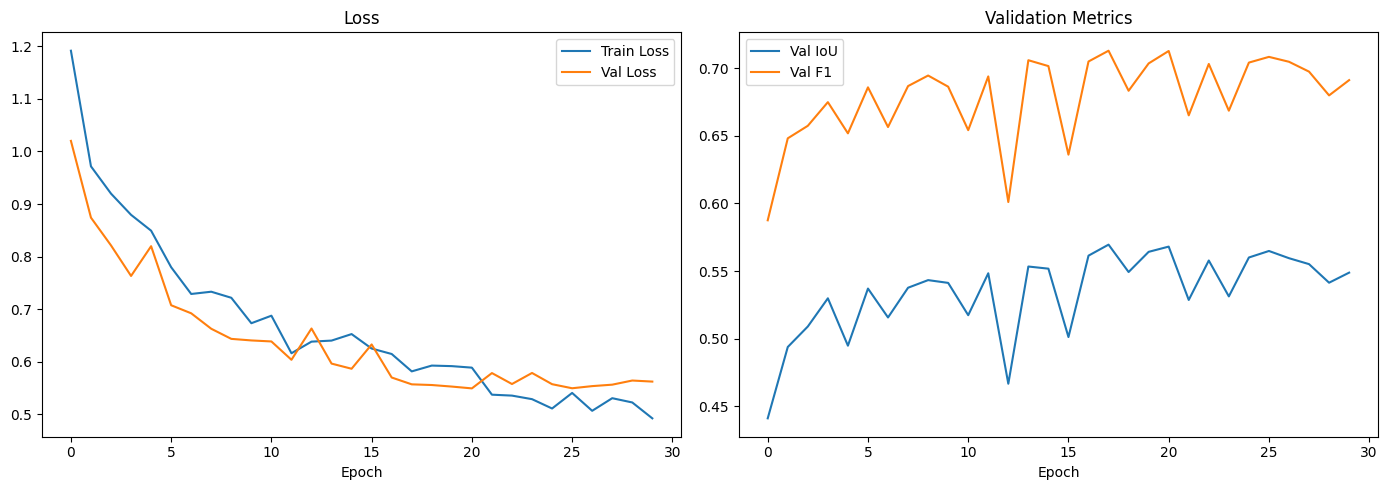

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"],   label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["val_iou"], label="Val IoU")
axes[1].plot(history["val_f1"],  label="Val F1")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

test_iou, test_f1, test_precision, test_recall = 0.0, 0.0, 0.0, 0.0

with torch.no_grad():
    for sar, mask in test_loader:
        sar, mask       = sar.to(DEVICE), mask.to(DEVICE)
        pred            = model(sar)
        iou, f1, prec, rec = compute_metrics(pred, mask)
        test_iou       += iou
        test_f1        += f1
        test_precision += prec
        test_recall    += rec

test_iou       /= len(test_loader)
test_f1        /= len(test_loader)
test_precision /= len(test_loader)
test_recall    /= len(test_loader)

print(f"Final Test IoU:       {test_iou:.4f}")
print(f"Final Test F1:        {test_f1:.4f}")
print(f"Final Test Precision: {test_precision:.4f}")
print(f"Final Test Recall:    {test_recall:.4f}")

Final Test IoU:       0.5485
Final Test F1:        0.6906
Final Test Precision: 0.7040
Final Test Recall:    0.7020


Freeze encoder


In [34]:
def freeze_encoder(model):
    for param in model.encoder.parameters():
        param.requires_grad = False
    frozen    = sum(p.numel() for p in model.encoder.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Encoder frozen ✅")
    print(f"Frozen params:    {frozen:,}")
    print(f"Trainable params: {trainable:,}")

def unfreeze_encoder(model):
    for param in model.encoder.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Encoder unfrozen ✅")
    print(f"Trainable params: {trainable:,}")

In [35]:
# Rebuild model
model2 = smp.Unet(
    encoder_name    = "resnet50",
    encoder_weights = None,
    in_channels     = 2,
    classes         = 1,
    activation      = None
)

# Reload SSL4EO-S12 weights into encoder
timm_resnet2 = timm.create_model('resnet50', in_chans=2, num_classes=0, pretrained=False)
timm_resnet2.load_state_dict(weights.get_state_dict(progress=False), strict=False)
model2.encoder.load_state_dict(timm_resnet2.state_dict(), strict=False)

model2 = model2.to(DEVICE)
print("Frozen model ready ")

CKPT_PATH2 = "/content/drive/MyDrive/best_flood_model_v2.pth"

Frozen model ready 


In [37]:
PHASE1_EPOCHS = 20
PHASE2_EPOCHS = 20
NUM_EPOCHS2   = PHASE1_EPOCHS + PHASE2_EPOCHS  # 40 total

best_val_iou2 = 0.0
history2      = {"train_loss": [], "val_loss": [], "val_iou": [], "val_f1": []}

# ── Phase 1 setup — freeze encoder ─────────────────────
freeze_encoder(model2)

optimizer2 = AdamW(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler2 = CosineAnnealingLR(optimizer2, T_max=PHASE1_EPOCHS, eta_min=1e-6)

print(f"\n{'='*55}")
print(f"PHASE 1 — encoder frozen, decoder learning only")
print(f"{'='*55}\n")

for epoch in range(NUM_EPOCHS2):

    # ── Switch to Phase 2 ───────────────────────────────
    if epoch == PHASE1_EPOCHS:
        print(f"\n{'='*55}")
        print(f"PHASE 2 — encoder unfrozen, full fine-tuning")
        print(f"{'='*55}\n")

        unfreeze_encoder(model2)

        optimizer2 = AdamW([
            {"params": model2.encoder.parameters(), "lr": 1e-5},
            {"params": model2.decoder.parameters(), "lr": 1e-5},
        ], weight_decay=1e-4)
        scheduler2 = CosineAnnealingLR(optimizer2, T_max=PHASE2_EPOCHS, eta_min=1e-7)

    #  Train
    model2.train()
    train_loss = 0.0

    for sar, mask in train_loader:
        sar, mask = sar.to(DEVICE), mask.to(DEVICE)
        optimizer2.zero_grad()
        pred  = model2(sar)
        loss  = loss_fn(pred, mask)
        loss.backward()
        optimizer2.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    #  Validate
    model2.eval()
    val_loss, val_iou, val_f1 = 0.0, 0.0, 0.0

    with torch.no_grad():
        for sar, mask in val_loader:
            sar, mask = sar.to(DEVICE), mask.to(DEVICE)
            pred      = model2(sar)
            loss      = loss_fn(pred, mask)
            iou, f1,_,_   = compute_metrics(pred, mask)
            val_loss += loss.item()
            val_iou  += iou
            val_f1   += f1

    val_loss /= len(val_loader)
    val_iou  /= len(val_loader)
    val_f1   /= len(val_loader)
    scheduler2.step()

    #  Save best
    if val_iou > best_val_iou2:
        best_val_iou2 = val_iou
        torch.save(model2.state_dict(), CKPT_PATH2)
        saved = "✅ saved"
    else:
        saved = ""

    phase = "P1" if epoch < PHASE1_EPOCHS else "P2"
    history2["train_loss"].append(train_loss)
    history2["val_loss"].append(val_loss)
    history2["val_iou"].append(val_iou)
    history2["val_f1"].append(val_f1)

    print(f"[{phase}] Epoch {epoch+1:02d}/{NUM_EPOCHS2} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val IoU: {val_iou:.4f} | "
          f"Val F1: {val_f1:.4f} {saved}")

print(f"\nBest Val IoU: {best_val_iou2:.4f}")

Encoder frozen ✅
Frozen params:    23,504,896
Trainable params: 9,013,073

PHASE 1 — encoder frozen, decoder learning only

[P1] Epoch 01/40 | Train Loss: 1.3592 | Val Loss: 1.3484 | Val IoU: 0.3953 | Val F1: 0.5468 ✅ saved
[P1] Epoch 02/40 | Train Loss: 1.2362 | Val Loss: 1.2427 | Val IoU: 0.4679 | Val F1: 0.6234 ✅ saved
[P1] Epoch 03/40 | Train Loss: 1.1709 | Val Loss: 1.1547 | Val IoU: 0.4934 | Val F1: 0.6514 ✅ saved
[P1] Epoch 04/40 | Train Loss: 1.0922 | Val Loss: 1.0160 | Val IoU: 0.5239 | Val F1: 0.6743 ✅ saved
[P1] Epoch 05/40 | Train Loss: 1.0330 | Val Loss: 1.1096 | Val IoU: 0.4981 | Val F1: 0.6551 
[P1] Epoch 06/40 | Train Loss: 0.9726 | Val Loss: 0.9531 | Val IoU: 0.5375 | Val F1: 0.6889 ✅ saved
[P1] Epoch 07/40 | Train Loss: 0.9619 | Val Loss: 0.9005 | Val IoU: 0.5388 | Val F1: 0.6897 ✅ saved
[P1] Epoch 08/40 | Train Loss: 0.9152 | Val Loss: 0.8597 | Val IoU: 0.5405 | Val F1: 0.6909 ✅ saved
[P1] Epoch 09/40 | Train Loss: 0.8900 | Val Loss: 0.8746 | Val IoU: 0.5264 | Val F1

In [38]:
model2.load_state_dict(torch.load(CKPT_PATH2, map_location=DEVICE))
model2.eval()

test_iou, test_f1, test_precision, test_recall = 0.0, 0.0, 0.0, 0.0

with torch.no_grad():
    for sar, mask in test_loader:
        sar, mask          = sar.to(DEVICE), mask.to(DEVICE)
        pred               = model2(sar)
        iou, f1, prec, rec = compute_metrics(pred, mask)
        test_iou          += iou
        test_f1           += f1
        test_precision    += prec
        test_recall       += rec

test_iou       /= len(test_loader)
test_f1        /= len(test_loader)
test_precision /= len(test_loader)
test_recall    /= len(test_loader)

print("="*40)
print(f"        MODEL COMPARISON")
print("="*40)
print(f"              v1 (30ep)   v2 (40ep 2-phase)")
print(f"  IoU:        0.5485      {test_iou:.4f}")
print(f"  F1:         0.6906      {test_f1:.4f}")
print(f"  Precision:  0.7040      {test_precision:.4f}")
print(f"  Recall:     0.7020      {test_recall:.4f}")
print("="*40)

        MODEL COMPARISON
              v1 (30ep)   v2 (40ep 2-phase)
  IoU:        0.5485      0.5319
  F1:         0.6906      0.6799
  Precision:  0.7040      0.6496
  Recall:     0.7020      0.7312
